#### COLLECTING DATA THROUGH API

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
url = "https://api.worldbank.org/v2/country/all/indicator/SP.POP.TOTL?format=json&per_page=10000"

response = requests.get(url)

data = response.json()

df = pd.json_normalize(data[1])
df.head()

,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,AFE,2025,NaN,,,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern
1,AFE,2024,769280888.0,,,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern
2,AFE,2023,750491370.0,,,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern
3,AFE,2022,731821393.0,,,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern
4,AFE,2021,713090928.0,,,0,SP.POP.TOTL,"Population, total",ZH,Africa Eastern and Southern


In [5]:
df.to_csv("global_population_data.csv", index=False)

#### EXPLORING DATA (EDA)

In [7]:
df.describe()

,value,decimal
count,9.783000e+03,10000.0
mean,3.710530e+08,0.0
std,9.173127e+08,0.0
min,7.950000e+03,0.0
25%,1.661044e+06,0.0
50%,1.040513e+07,0.0
75%,2.874664e+08,0.0
max,8.141809e+09,0.0


In [9]:
df.shape

(10000, 10)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  10000 non-null  object 
 1   date             10000 non-null  object 
 2   value            9783 non-null   float64
 3   unit             10000 non-null  object 
 4   obs_status       10000 non-null  object 
 5   decimal          10000 non-null  int64  
 6   indicator.id     10000 non-null  object 
 7   indicator.value  10000 non-null  object 
 8   country.id       10000 non-null  object 
 9   country.value    10000 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 781.4+ KB


In [13]:
df.isnull().sum()

countryiso3code      0
date                 0
value              217
unit                 0
obs_status           0
decimal              0
indicator.id         0
indicator.value      0
country.id           0
country.value        0
dtype: int64

In [15]:
df.columns

Index(['countryiso3code', 'date', 'value', 'unit', 'obs_status', 'decimal',
       'indicator.id', 'indicator.value', 'country.id', 'country.value'],
      dtype='object')

In [17]:
(df['decimal']!=1).count()

10000

In [19]:
df['decimal'].unique()

array([0])

In [21]:
df.drop(columns = 'decimal', inplace = True)

In [23]:
(df['indicator.id'] == 'SP.POP.TOTL').sum()

10000

In [25]:
df.drop(columns = 'indicator.id', inplace = True)

In [27]:
(df['indicator.value'] == 'Population, total').sum()

10000

In [29]:
df.drop(columns = 'indicator.value', inplace = True)

In [31]:
remove_list = [
    'World', 'IDA & IBRD total', 'Low & middle income',
    'Middle income', 'IBRD only', 'Upper middle income',
    'Lower middle income', 'East Asia & Pacific',
    'Early-demographic dividend', 'Late-demographic dividend'
]

df = df[~df['country.value'].isin(remove_list)]

In [33]:
df

,countryiso3code,date,value,unit,obs_status,country.id,country.value
0,AFE,2025,NaN,,,ZH,Africa Eastern and Southern
1,AFE,2024,769280888.0,,,ZH,Africa Eastern and Southern
2,AFE,2023,750491370.0,,,ZH,Africa Eastern and Southern
3,AFE,2022,731821393.0,,,ZH,Africa Eastern and Southern
4,AFE,2021,713090928.0,,,ZH,Africa Eastern and Southern
...,...,...,...,...,...,...,...
9995,KIR,1996,82623.0,,,KI,Kiribati
9996,KIR,1995,81234.0,,,KI,Kiribati
9997,KIR,1994,80021.0,,,KI,Kiribati
9998,KIR,1993,78841.0,,,KI,Kiribati


In [35]:
df.isnull().sum()

countryiso3code      0
date                 0
value              207
unit                 0
obs_status           0
country.id           0
country.value        0
dtype: int64

In [37]:
df['value'] = df.groupby('country.value')['value'].transform(lambda x: x.ffill().bfill())

In [39]:
df.isnull().sum()

countryiso3code     0
date                0
value              66
unit                0
obs_status          0
country.id          0
country.value       0
dtype: int64

In [41]:
df = df.dropna(subset=['value'])
df['date'] = df['date'].astype(int)

# Sort for time-based plots
df = df.sort_values(by=['country.value', 'date'])

/var/folders/jk/f_ysh6wj59v_wxwrqllkhj7m0000gn/T/ipykernel_59762/2950393009.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = df['date'].astype(int)


In [43]:
df.columns

Index(['countryiso3code', 'date', 'value', 'unit', 'obs_status', 'country.id',
       'country.value'],
      dtype='object')

In [45]:
df.drop(['obs_status', 'unit'], axis=1, inplace=True)

In [47]:
df

,countryiso3code,date,value,country.id,country.value
3299,AFG,1960,9.035043e+06,AF,Afghanistan
3298,AFG,1961,9.214083e+06,AF,Afghanistan
3297,AFG,1962,9.404406e+06,AF,Afghanistan
3296,AFG,1963,9.604487e+06,AF,Afghanistan
3295,AFG,1964,9.814318e+06,AF,Afghanistan
...,...,...,...,...,...
2974,SSA,2021,1.076774e+09,ZF,Sub-Saharan Africa (excluding high income)
2973,SSA,2022,1.103704e+09,ZF,Sub-Saharan Africa (excluding high income)
2972,SSA,2023,1.131078e+09,ZF,Sub-Saharan Africa (excluding high income)
2971,SSA,2024,1.158864e+09,ZF,Sub-Saharan Africa (excluding high income)


In [49]:
df['country.value'].nunique()

141

In [51]:
df['countryiso3code'].nunique()

140

In [53]:
df['country.id'].nunique()

141

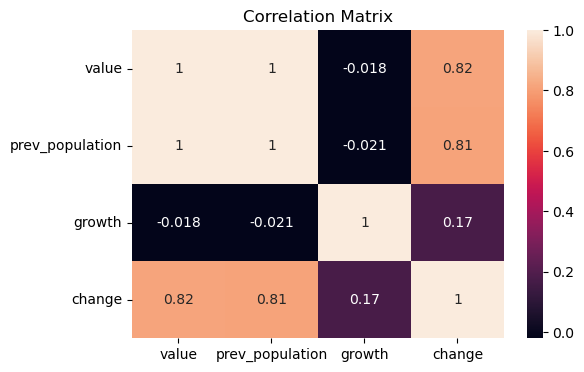

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
corr_matrix = df[['value','prev_population','growth','change']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True)
plt.title("Correlation Matrix")
plt.show()

<Figure size 1000x500 with 0 Axes>

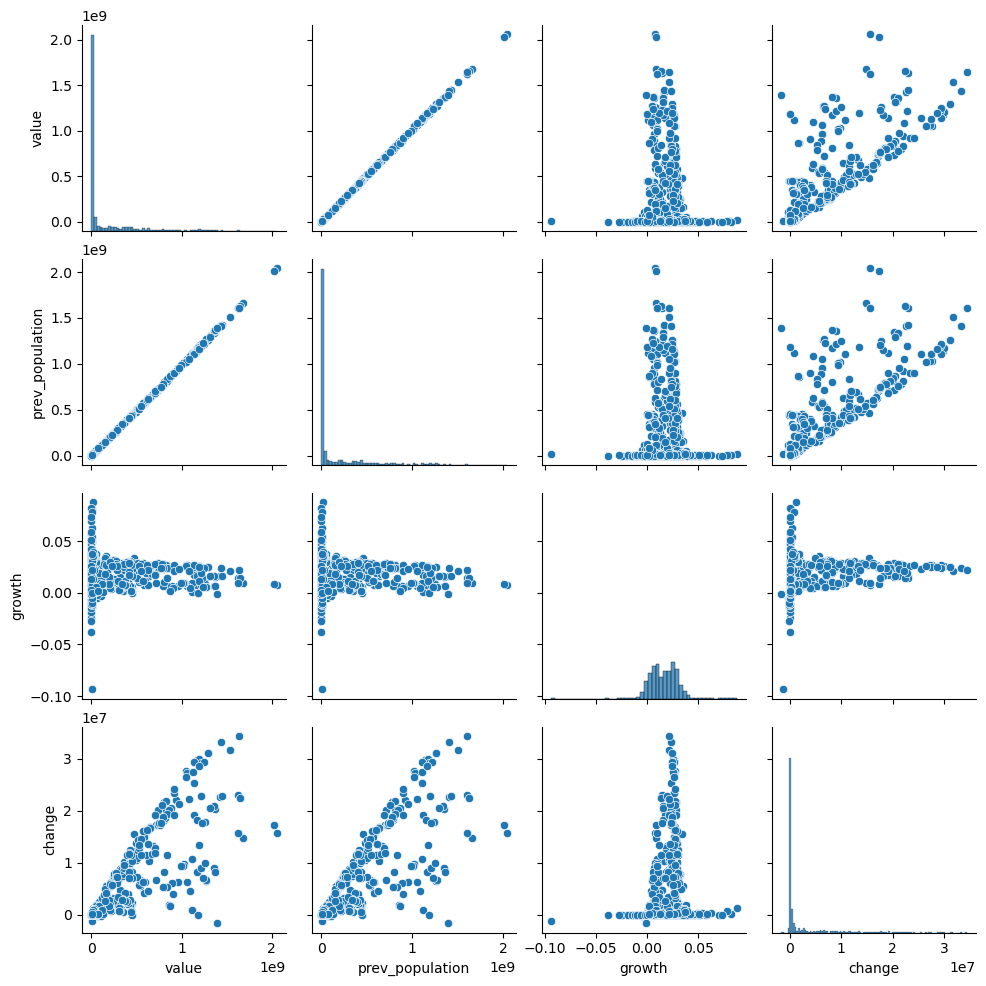

In [132]:
df_sample = df.sample(1000)
plt.figure(figsize=(10, 5))
sns.pairplot(df_sample[['value','prev_population','growth','change']])
plt.show()

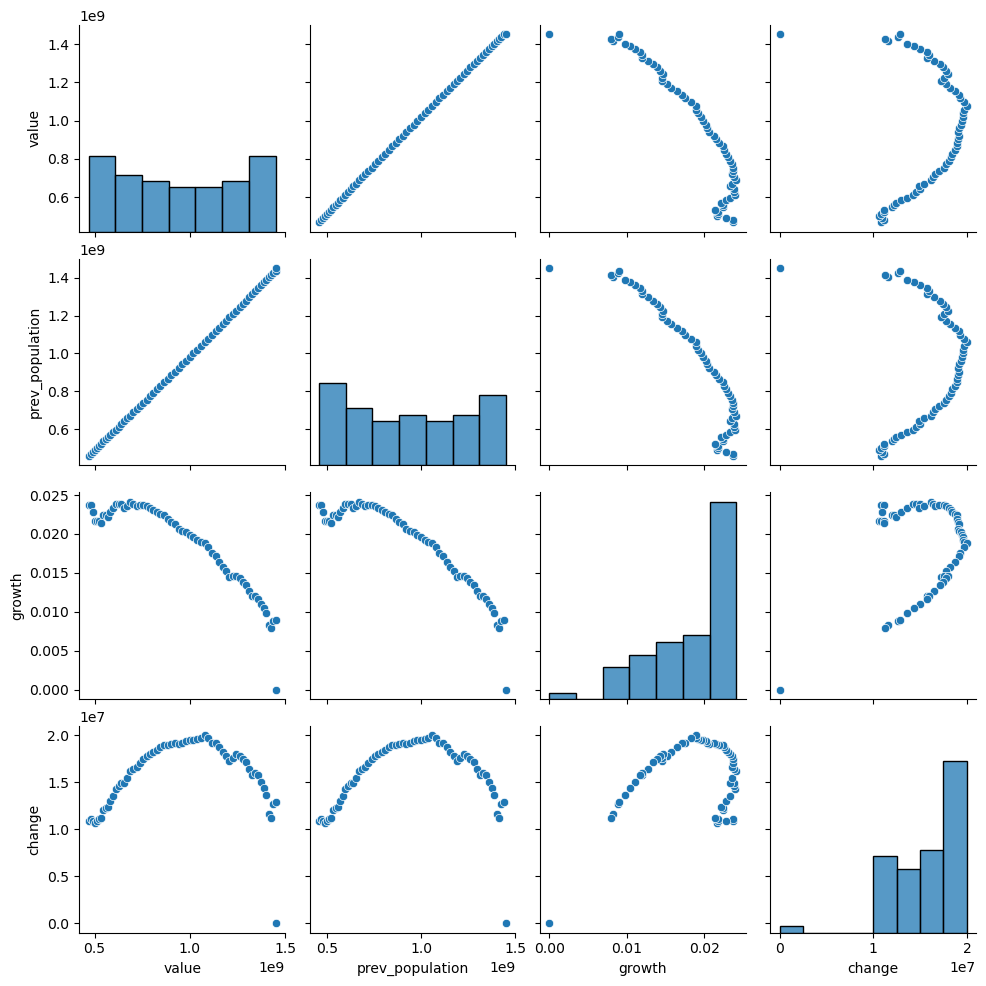

In [134]:
india = df[df['country.value'] == 'India']

sns.pairplot(india[['value','prev_population','growth','change']])
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


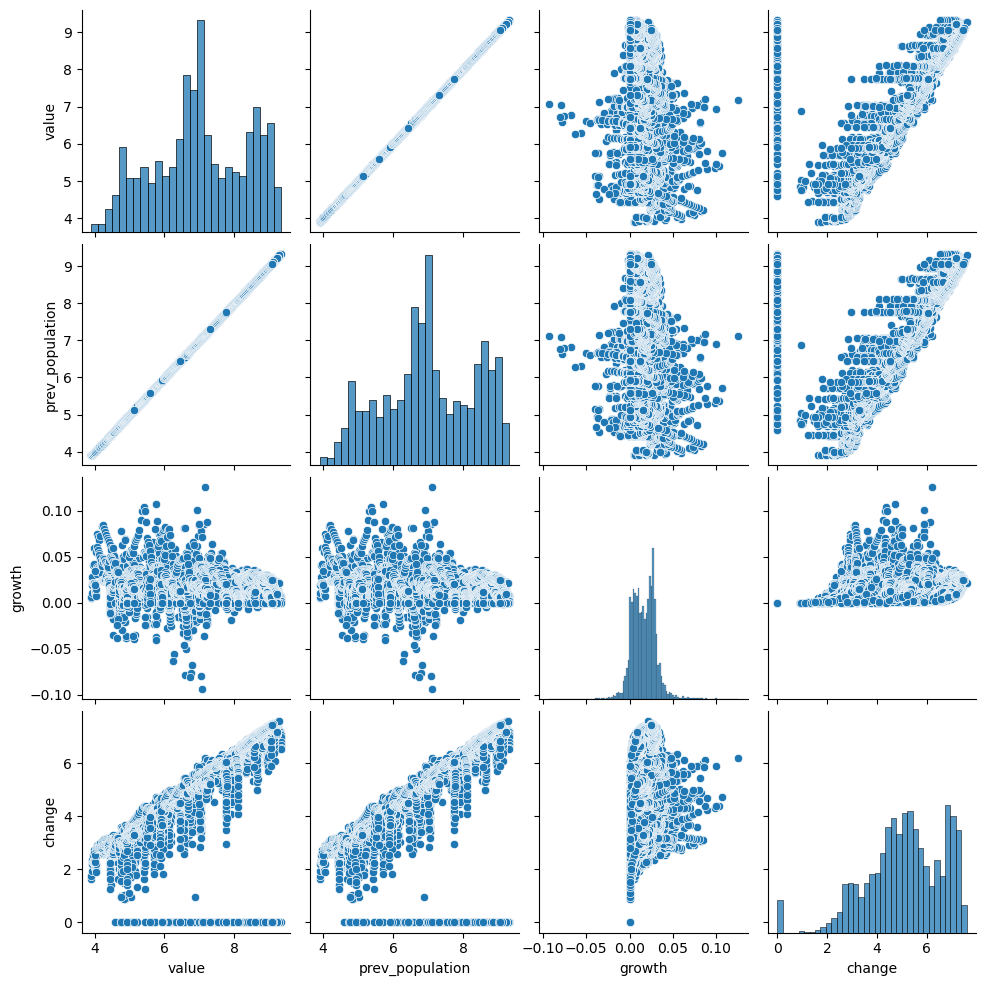

In [136]:
import numpy as np

df_sample = df.copy()
df_sample['value'] = np.log10(df_sample['value'])
df_sample['prev_population'] = np.log10(df_sample['prev_population'])
df_sample['change'] = np.log10(df_sample['change'] + 1)

import seaborn as sns
sns.pairplot(df_sample[['value','prev_population','growth','change']])
plt.show()

In [138]:
cov_matrix = df[['value','prev_population','growth','change']].cov()

print("Covariance Matrix:")
cov_matrix

Covariance Matrix:


,value,prev_population,growth,change
value,1.290766e+17,1.273667e+17,-89570.427373,1.709955e+15
prev_population,1.273667e+17,1.256907e+17,-103946.519373,1.675935e+15
growth,-8.957043e+04,-1.039465e+05,0.000200,1.437609e+04
change,1.709955e+15,1.675935e+15,14376.092000,3.401974e+13


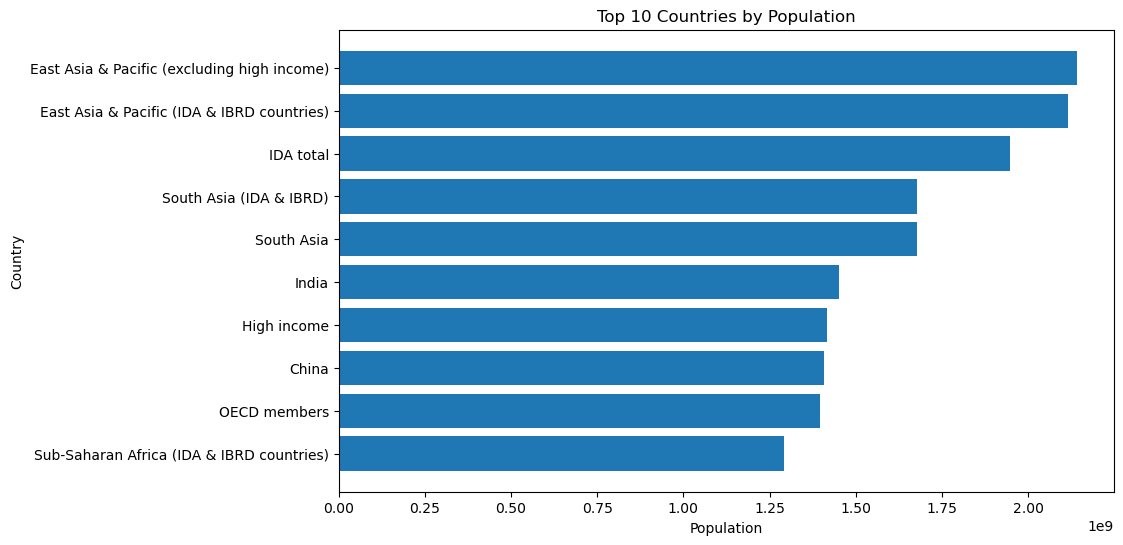

In [140]:
latest = df[df['date'] == df['date'].max()]
top10 = latest.sort_values(by='value', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['country.value'], top10['value'])
plt.title("Top 10 Countries by Population")
plt.xlabel("Population")
plt.ylabel("Country")
plt.gca().invert_yaxis()
plt.show()

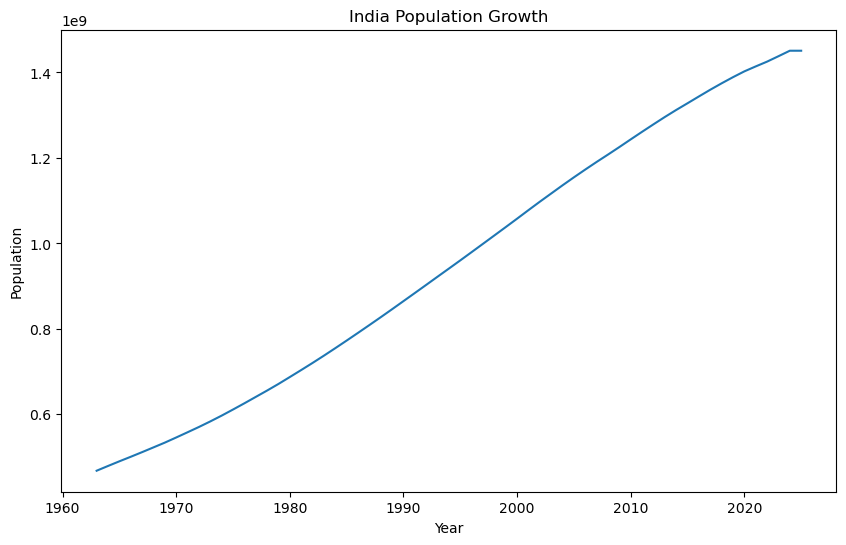

In [142]:
india = df[df['country.value'] == 'India']

plt.figure(figsize=(10,6))
plt.plot(india['date'], india['value'])
plt.title("India Population Growth")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

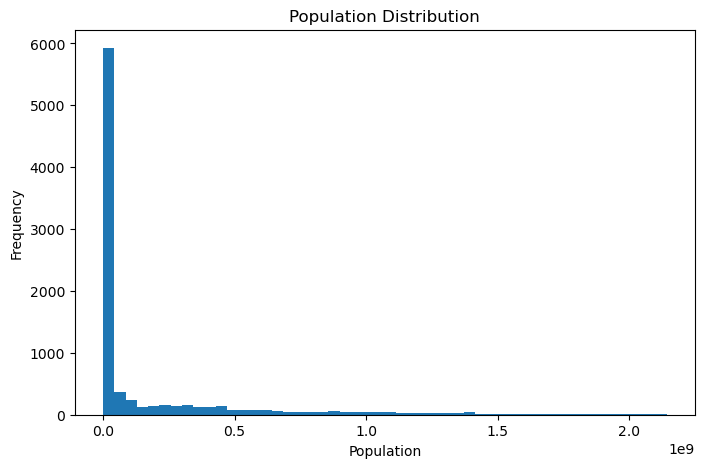

In [144]:
plt.figure(figsize=(8,5))
plt.hist(df['value'], bins=50)
plt.title("Population Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")
plt.show()

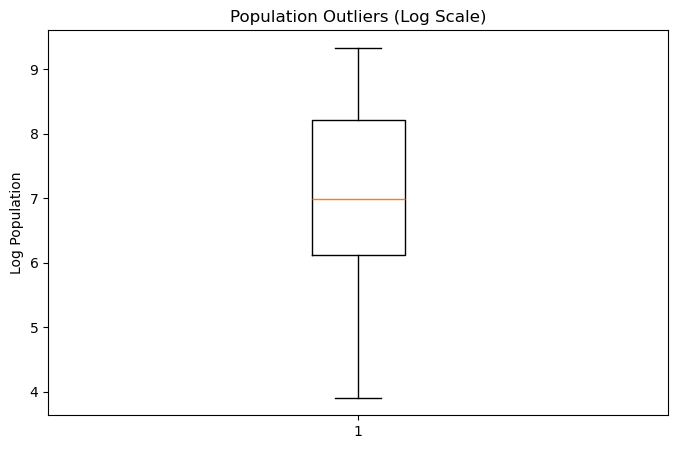

In [146]:
import numpy as np

plt.figure(figsize=(8,5))
plt.boxplot(np.log10(df['value']))
plt.title("Population Outliers (Log Scale)")
plt.ylabel("Log Population")
plt.show()

In [148]:
df = df.sort_values(by=['country.value','date'])

df['prev_population'] = df.groupby('country.value')['value'].shift(1)
df['growth'] = df.groupby('country.value')['value'].pct_change()

df = df.dropna()

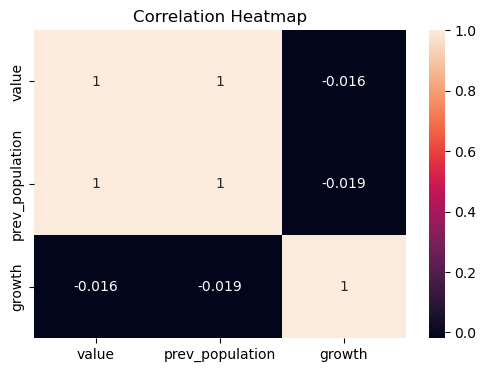

In [150]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df[['value','prev_population','growth']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

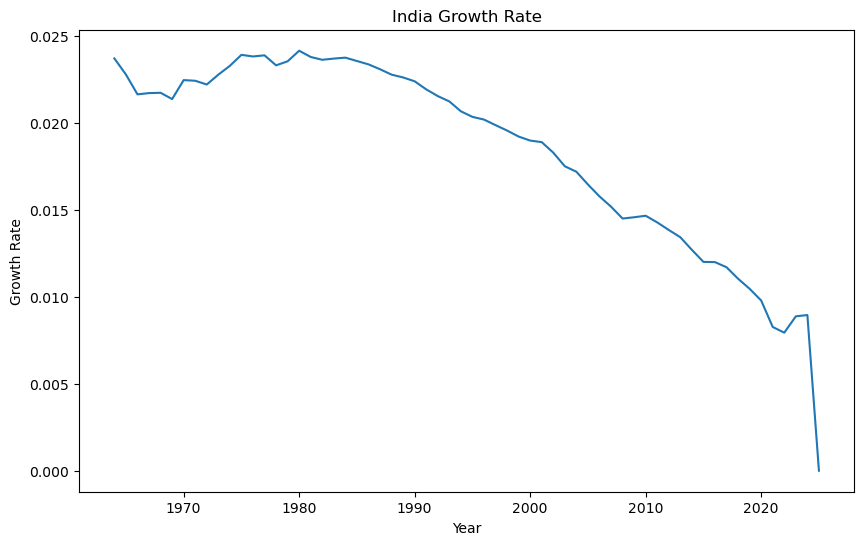

In [152]:
india = df[df['country.value'] == 'India']

plt.figure(figsize=(10,6))
plt.plot(india['date'], india['growth'])
plt.title("India Growth Rate")
plt.xlabel("Year")
plt.ylabel("Growth Rate")
plt.show()

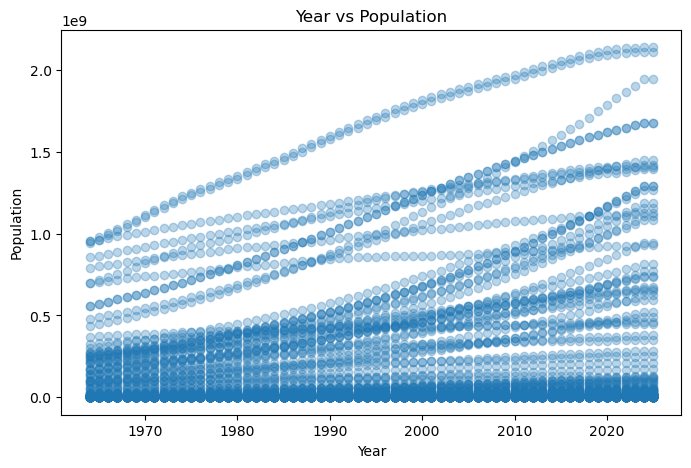

In [154]:
plt.figure(figsize=(8,5))
plt.scatter(df['date'], df['value'], alpha=0.3)
plt.title("Year vs Population")
plt.xlabel("Year")
plt.ylabel("Population")
plt.show()

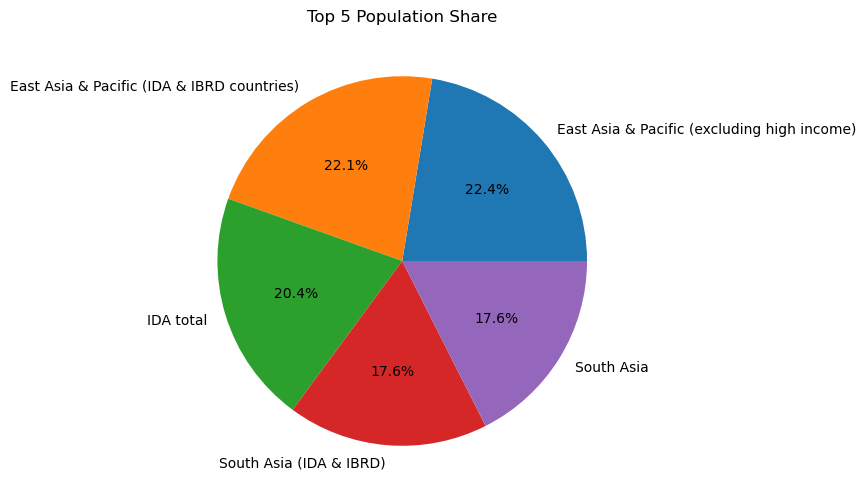

In [156]:
top5 = latest.sort_values(by='value', ascending=False).head(5)

plt.figure(figsize=(6,6))
plt.pie(top5['value'], labels=top5['country.value'], autopct='%1.1f%%')
plt.title("Top 5 Population Share")
plt.show()

In [158]:
df = df.sort_values(by=['country.value', 'date'])
# Previous year population
df['prev_population'] = df.groupby('country.value')['value'].shift(1)
df['growth'] = df.groupby('country.value')['value'].pct_change()
df['change'] = df['value'] - df['prev_population']
df = df.dropna()

In [160]:
df_encoded = pd.get_dummies(df, columns=['country.value'])

X = df_encoded[['date'] + [col for col in df_encoded.columns if 'country.value_' in col]]
y = df_encoded['value']

In [162]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 66081414.67211202
R2 Score: 0.9191367164563832


In [164]:
df.shape

(8569, 8)

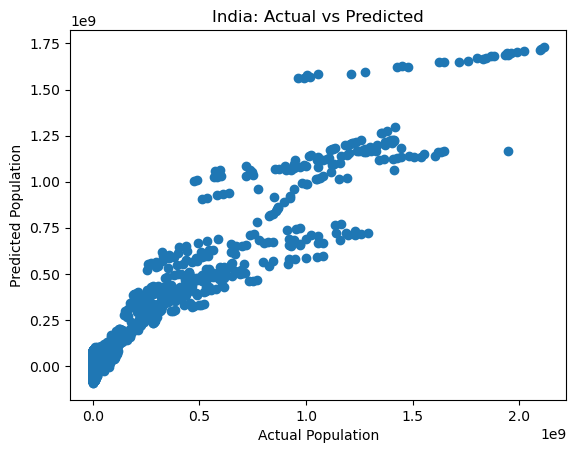

In [167]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("India: Actual vs Predicted")
plt.show()